# EPV에 사용할 PASS데이터의 feature를 정의함

- 총 13개의 channel를 구할 것이고, 각 channel의 size는 104x68

1. 각 pixel에 우리팀 선수들이 존재하면 1, 아니면 0인 sparse matrix
2. 각 pixel에 우리팀 선수들의 x축방향 기준 속도벡터 값 sparse matrix
3. 각 pixel에 우리팀 선수들의 y축방향 기준 속도벡터 값 sparse matrix

4. 각 pixel에 상대팀 선수들이 존재하면 1, 아니면 0인 sparse matrix
5. 각 pixel에 상대팀 선수들의 x축방향 기준 속도벡터 값 sparse matrix
6. 각 pixel에 상대팀 선수들의 y축방향 기준 속도벡터 값 sparse matrix

7. 모든 pixel에서 골까지 거리 dense matrix
8. 모든 pixel에서 공까지 거리 dense matrix

9. 모든 pixel에서 골까지 각도 dense matrix(pixel-양쪽 골대 끝 사이를 잇을때 나오는 Radian)

10. 모든 pixel에서 골-공 사이 sin값 dense matrix(pixel중앙-골 & pixcel중앙-공 두 벡터 사이의 sin값)
11. 모든 pixel에서 골-공 사이 cos값 dense matrix(pixel중앙-골 & pixcel중앙-공 두 벡터 사이의 cos값)

-soccer map에선 같은 팀원만 계산한 sparse matrix<br/>
-EPV에서 모든 pixel로 계산한 dense matrix<br/>
12. 모든 pixel(or 같은 팀원)과 볼 소유자의 속도벡터 사이의 sin<br/>
13. 모든 pixel(or 같은 팀원)과 볼 소유자의 속도벡터 사이의 cos<br/>

In [20]:

import numpy as np
import pandas as pd
import os
import math
from mplsoccer import Pitch
import tqdm

In [2]:
pass_df = pd.read_csv('./statsbomb360 data/preprocess_pass_data',index_col=0)

In [3]:
pass_df

,type_name,type,pass_type,result_name,pass_outcome,freeze_frame,location,pass_end_location,pass_angle,pass_length,player_id_x,player_name
0,pass,Pass,Recovery,fail,Incomplete,"[{'teammate': True, 'actor': False, 'keeper': ...","[43.8, 52.2]","[43.2, 52.2]",3.141593,0.600000,10167.0,Tatiana Pinto
1,pass,Pass,Recovery,fail,Incomplete,"[{'teammate': True, 'actor': False, 'keeper': ...","[76.9, 27.9]","[71.8, 30.7]",2.639502,5.818075,26093.0,Gun Nathalie Björn
2,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': True, 'keeper': F...","[34.1, 51.2]","[20.1, 39.1]",-2.428863,18.504324,32143.0,Diana Gomes
3,pass,Pass,NaN,fail,Incomplete,"[{'teammate': True, 'actor': True, 'keeper': T...","[22.9, 34.8]","[35.1, 13.0]",-1.060587,24.981594,10145.0,Patricia Sousa
4,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[108.6, 35.8]","[110.0, 47.9]",1.455606,12.180722,10215.0,Fridolina Rolfö
...,...,...,...,...,...,...,...,...,...,...,...,...
114549,pass,Pass,Recovery,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[30.2, 61.8]","[49.9, 57.9]",-0.195442,20.082330,31900.0,Oleksandr Karavaev
114550,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[49.9, 57.9]","[54.8, 44.3]",-1.224980,14.455794,16509.0,Viktor Tsygankov
114551,pass,Pass,NaN,fail,Incomplete,"[{'teammate': True, 'actor': False, 'keeper': ...","[54.8, 44.3]","[43.4, 41.3]",-2.884269,11.788130,18881.0,Artem Besedin
114552,pass,Pass,Recovery,success,NaN,"[{'teammate': False, 'actor': False, 'keeper':...","[76.7, 38.8]","[84.7, 54.7]",1.104636,17.799158,30322.0,Darko Churlinov


### 1.freeze_frame 탐색

- freeze_frame은 기존 리스트형식이었지만, pd.read_csv는 모든 데이터를 문자열 형식으로 불러오므로 다시 리스트 형식으로 변환해야함

In [4]:
print("freeze_frame type : ",type(pass_df['freeze_frame'][0]))
pass_df['freeze_frame'][0]

freeze_frame type :  <class 'str'>


"[{'teammate': True, 'actor': False, 'keeper': False, 'location': [31.400613706521398, 32.43142662079095]}, {'teammate': True, 'actor': False, 'keeper': False, 'location': [31.945485115847973, 44.312870410312314]}, {'teammate': True, 'actor': False, 'keeper': False, 'location': [32.689707440624574, 53.92121870203451]}, {'teammate': False, 'actor': False, 'keeper': False, 'location': [39.97855875363328, 45.5539442092169]}, {'teammate': False, 'actor': False, 'keeper': False, 'location': [42.115595107845806, 58.01732404862158]}, {'teammate': True, 'actor': True, 'keeper': False, 'location': [43.79999923706055, 52.20000076293945]}, {'teammate': True, 'actor': False, 'keeper': False, 'location': [47.4484536318147, 52.98027732894058]}, {'teammate': False, 'actor': False, 'keeper': False, 'location': [47.81127419374195, 20.2117089800211]}, {'teammate': True, 'actor': False, 'keeper': False, 'location': [48.95453633022329, 22.083705928939132]}, {'teammate': True, 'actor': False, 'keeper': Fal

In [5]:
import ast
pass_df['freeze_frame'] = pass_df['freeze_frame'].apply(ast.literal_eval)

1. teammate : 우리팀 선수인지 유무
2. actor : 공을 소유한 선수인지 유무
3. keeper : 골키퍼인지 유무
4. location : 포착된 선수들의 위치

In [6]:
print("freeze_frame type : ",type(pass_df['freeze_frame'][0]))
pass_df['freeze_frame'][0]

freeze_frame type :  <class 'list'>


[{'teammate': True,
  'actor': False,
  'keeper': False,
  'location': [31.400613706521398, 32.43142662079095]},
 {'teammate': True,
  'actor': False,
  'keeper': False,
  'location': [31.945485115847973, 44.312870410312314]},
 {'teammate': True,
  'actor': False,
  'keeper': False,
  'location': [32.689707440624574, 53.92121870203451]},
 {'teammate': False,
  'actor': False,
  'keeper': False,
  'location': [39.97855875363328, 45.5539442092169]},
 {'teammate': False,
  'actor': False,
  'keeper': False,
  'location': [42.115595107845806, 58.01732404862158]},
 {'teammate': True,
  'actor': True,
  'keeper': False,
  'location': [43.79999923706055, 52.20000076293945]},
 {'teammate': True,
  'actor': False,
  'keeper': False,
  'location': [47.4484536318147, 52.98027732894058]},
 {'teammate': False,
  'actor': False,
  'keeper': False,
  'location': [47.81127419374195, 20.2117089800211]},
 {'teammate': True,
  'actor': False,
  'keeper': False,
  'location': [48.95453633022329, 22.083705

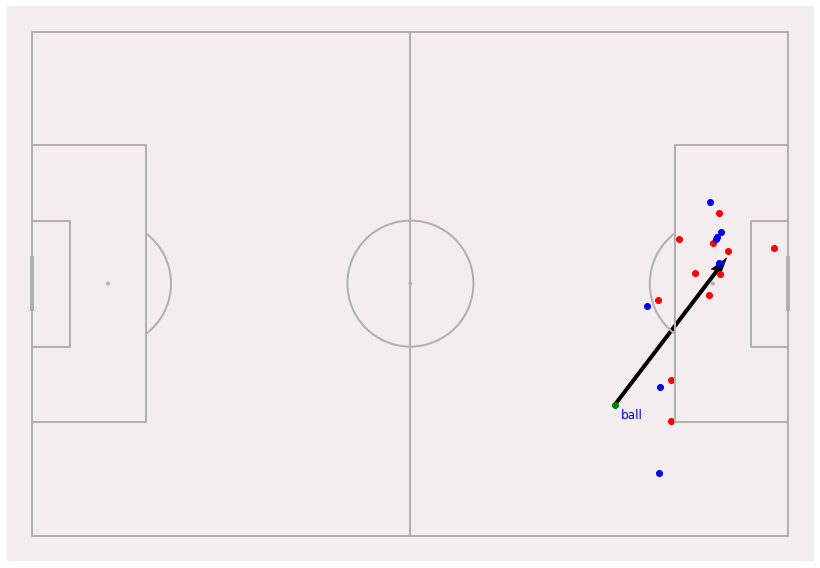

In [7]:
pitch = Pitch(line_zorder=2, pitch_color='#f4edf0')
fig, ax = pitch.draw(figsize=(12,8))

#1455번째 pass 시각화
i = 36337
start_x, start_y = map(float, pass_df.location[i].strip('[]').split(','))
end_x, end_y = map(float, pass_df.pass_end_location[i].strip('[]').split(','))

ax.text(x=start_x+1,y=start_y+2,s="ball",color='blue',fontsize=12)
pitch.arrows(xstart=start_x,ystart=start_y,xend=end_x,yend=end_y,ax=ax)

for x in pass_df.iloc[i]['freeze_frame']:
    #볼 소유자 팀원은 blue, 상대팀원은 red
    if x['teammate']:
        color='blue'
    else:
        color='red'
    
    #볼 소유자는 green
    if x['actor']:
        color='green'
        
    pitch.scatter(x=x['location'][0],y=x['location'][1],ax=ax,c=color)

### 2. Feature 전처리

-위에서 정의한 13가지 feature중 StatsBomb360데이터에서 활용할 수 있는 feature정의하기

### 1. Possession team player's location 

- 각 pixel에 우리팀 선수들이 존재하면 1, 아니면 0인 sparse matrix
- 여러명이 존재할시 해당 인원수만큼으로 값 부여<br/>

In [8]:
Possession_team_location_sparse_matrix = np.zeros((len(pass_df), 68, 104))
pitch = Pitch(line_zorder=2)

for i in tqdm.tqdm(range(len(pass_df))):
    location_df = pd.DataFrame(columns=['x', 'y'])
    index = 0
    for coordinate in pass_df.iloc[i]['freeze_frame']:
        #같은 팀 선수들의 위치 정보만 matrix에 저장
        if coordinate['teammate']:
            location_df.loc[index] = [coordinate['location'][0], coordinate['location'][1]]
            index+=1
    Possession_team_location_sparse_matrix[i] = pitch.bin_statistic(location_df['x'], location_df['y'], bins=(104, 68))['statistic']

  0%|          | 0/114554 [00:00<?, ?it/s]

100%|██████████| 114554/114554 [15:02<00:00, 126.86it/s]


### 4. Opponent team player's location

- 각 pixel에 상대팀 선수들이 존재하면 1, 아니면 0인 sparse matrix
- 여러명이 존재할시 해당 인원수만큼으로 값 부여<br/>

In [11]:
Opponent_team_location_sparse_matrix = np.zeros((len(pass_df), 68, 104))
pitch = Pitch(line_zorder=2)

for i in tqdm.tqdm(range(len(pass_df))):
    location_df = pd.DataFrame(columns=['x', 'y'])
    index = 0
    for coordinate in pass_df.iloc[i]['freeze_frame']:
        #상대 팀 선수들의 위치 정보만 matrix에 저장
        if not coordinate['teammate']:
            location_df.loc[index] = [coordinate['location'][0], coordinate['location'][1]]
            index+=1
    Opponent_team_location_sparse_matrix[i] = pitch.bin_statistic(location_df['x'], location_df['y'], bins=(104, 68))['statistic']

  0%|          | 0/114554 [00:00<?, ?it/s]

100%|██████████| 114554/114554 [15:10<00:00, 125.84it/s]


In [12]:
Possession_team_location_sparse_matrix.shape, Opponent_team_location_sparse_matrix.shape

((114554, 68, 104), (114554, 68, 104))

In [13]:
Possession_team_location_sparse_matrix[0].shape, Opponent_team_location_sparse_matrix[0].shape

((68, 104), (68, 104))

- 같은 pixel에 여러 선수가 존재하는 경우 존재함

- 여러 선수가 존재할 경우 1로 처리할 수도 있지만, 여기서는 해당 선수 인원만큼으로 값을 부여

In [14]:
result = False
for i in range(len(pass_df)):
    single_matrix = Possession_team_location_sparse_matrix[i]
    for row in range(68):
        for col in range(104):
            if single_matrix[row][col] > 2:
                print(f"{i}번째 pass_df는 {(row,col)}에 여러 선수가 존재함")
                result = True
            if result:
                break
        if result:
                break
                    

36337번째 pass_df는 (27, 94)에 여러 선수가 존재함


In [18]:
Possession_team_location_sparse_matrix[36337][27]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 3., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.])

In [19]:
Opponent_team_location_sparse_matrix[36337][27]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.])

- Possession team player location matrix 저장하기
- Opponent team player location matrix 저장하기

In [21]:
import numpy as np
import os

# 저장할 디렉토리 생성
directory = 'Feature Matrix/Possession location matrix'
os.makedirs(directory, exist_ok=True)

# 각각의 데이터를 파일로 저장
for i in tqdm.tqdm(range(len(Possession_team_location_sparse_matrix))):
    filename = os.path.join(directory, f'Possession_matrix_{i}.txt')
    with open(filename, 'w') as file:
        np.savetxt(file, Possession_team_location_sparse_matrix[i], delimiter=',')
        
directory = 'Feature Matrix/Opponent location matrix'
os.makedirs(directory, exist_ok=True)

# 각각의 데이터를 파일로 저장
for i in tqdm.tqdm(range(len(Opponent_team_location_sparse_matrix))):
    filename = os.path.join(directory, f'Opponent_matrix_{i}.txt')
    with open(filename, 'w') as file:
        np.savetxt(file, Opponent_team_location_sparse_matrix[i], delimiter=',')


100%|██████████| 114554/114554 [07:18<00:00, 261.11it/s]


### 7. Distance to the goal location

- 모든 pixel에서 골까지 거리 dense matrix
- 모든 pixel의 중앙 위치 - 골대중앙 사이의 거리
- 두 고정된 위치 사이의 거리 : 어느 data이든 항상 동일한 Matrix를 가짐

In [8]:
#골대 중앙을 위치
center_goal_location = (120,40)

color=['#FF0000', 'gold', 'coral', 'maroon', 'salmon', 'pink', 'aqua', 'orchid']

- 12x8 각 pixel의 중앙 위치 값
- 104x68 각 pixel의 중앙 위치 값

In [9]:
pixel_center_location_12x8 = pitch.bin_statistic(0, 0, bins=(12, 8))
pixel_center_location_104x68 = pitch.bin_statistic(0, 0, bins=(104, 68))

In [10]:
print("12x8 : ",pixel_center_location_12x8['cx'].shape)
print("12x8 : ",pixel_center_location_12x8['cy'].shape)
print("104x68 : ",pixel_center_location_104x68['cx'].shape)
print("104x68 : ",pixel_center_location_104x68['cy'].shape)

12x8 :  (8, 12)
12x8 :  (8, 12)
104x68 :  (68, 104)
104x68 :  (68, 104)


ex) 8x12구장에서 골까지 거리를 계산해보자

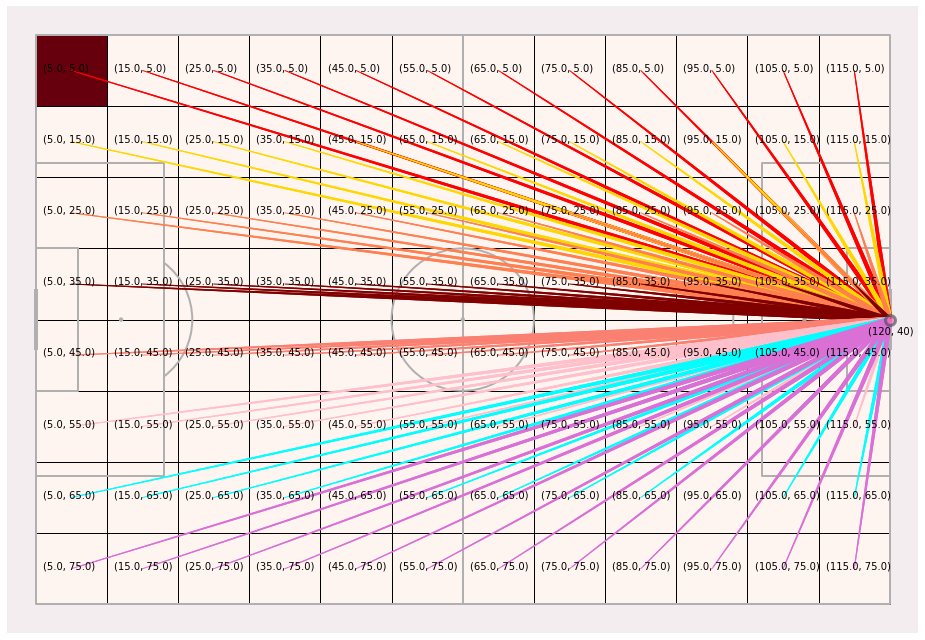

In [63]:
pitch = Pitch(line_zorder=2, pitch_color='#f4edf0')
fig, ax = pitch.draw(figsize=(18,9))

pitch.heatmap(pixel_center_location_12x8, ax=ax, cmap='Reds', edgecolor='black')
pitch.scatter(center_goal_location[0], center_goal_location[1],
              ax=ax, fc='hotpink',
              marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)
ax.text(center_goal_location[0]-3, center_goal_location[1]+2,
        s=f"{(center_goal_location[0], center_goal_location[1])}",color='black')

for i in range(8):
    for j in range(12):
        #각 pixel 중앙 pixel number
        ax.text(x=pixel_center_location_12x8['cx'][i][j]-4,
                y=pixel_center_location_12x8['cy'][i][j],
                s=f"{(pixel_center_location_12x8['cx'][i][j],pixel_center_location_12x8['cy'][i][j])}")
        
        #pixel중앙 - 골대 중앙 사이의 거리
        pitch.lines(xstart=pixel_center_location_12x8['cx'][i][j],
                    ystart=pixel_center_location_12x8['cy'][i][j],
                xend=center_goal_location[0],yend=center_goal_location[1],
                ax=ax, comet=True,color=color[i])

In [64]:
Distance_to_goal_dense_matrix_numpy_array = np.zeros((8,12))
for i in tqdm.tqdm(range(8)):
    for j in range(12):
        start_x, start_y = pixel_center_location_12x8['cx'][i][j], pixel_center_location_12x8['cy'][i][j]
        #골대 중앙 위치값
        end_x, end_y = center_goal_location[0], center_goal_location[1]
        
        #유클리디안 거리 계산
        distance = ((end_x-start_x)*(end_x-start_x) + (end_y-start_y)*(end_y-start_y))**0.5
        Distance_to_goal_dense_matrix_numpy_array[i][j] = distance

100%|██████████| 8/8 [00:00<00:00, 12676.40it/s]


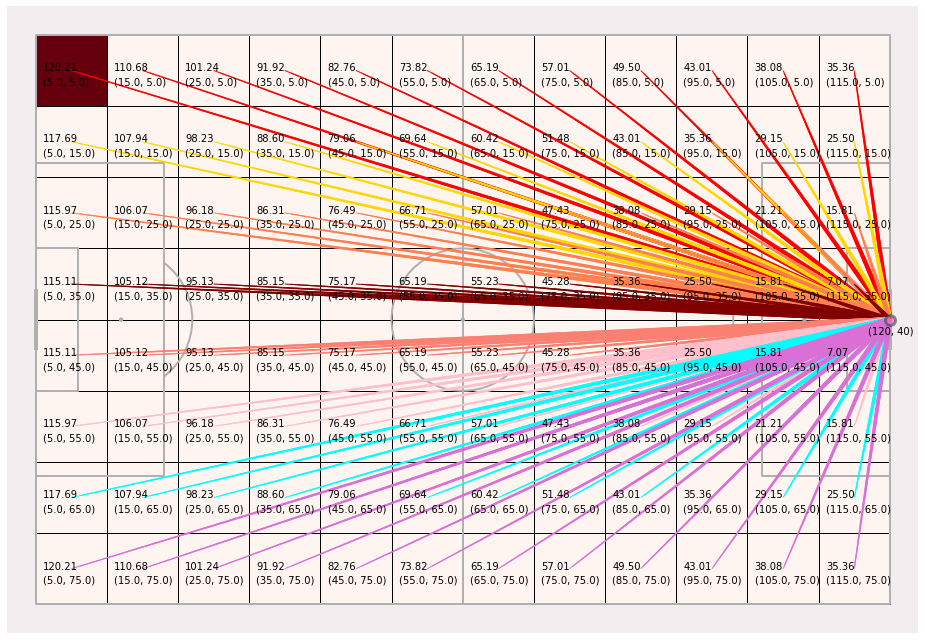

In [66]:
fig, ax = pitch.draw(figsize=(18,9))

pitch.heatmap(pixel_center_location_12x8, ax=ax, cmap='Reds', edgecolor='black')
pitch.scatter(center_goal_location[0], center_goal_location[1],
              ax=ax, fc='hotpink',
              marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)

ax.text(center_goal_location[0]-3, center_goal_location[1]+2,
        s=f"{(center_goal_location[0], center_goal_location[1])}",color='black')

for i in range(8):
    for j in range(12):
        #pixel중앙 - 골대 중앙 사이의 거리
        ax.text(x=pixel_center_location_12x8['cx'][i][j]-4,
                y=pixel_center_location_12x8['cy'][i][j],
                s=f"{Distance_to_goal_dense_matrix_numpy_array[i][j]:.2f}")
        
        #각 pixel 중앙에 pixel number
        ax.text(x=pixel_center_location_12x8['cx'][i][j]-4,
                y=pixel_center_location_12x8['cy'][i][j]+2,
                s=f"{(pixel_center_location_12x8['cx'][i][j],pixel_center_location_12x8['cy'][i][j])}")
        
        pitch.lines(xstart=pixel_center_location_12x8['cx'][i][j],
                    ystart=pixel_center_location_12x8['cy'][i][j],
                xend=center_goal_location[0],yend=center_goal_location[1],
                ax=ax, comet=True,color=color[i])


In [67]:
Distance_to_goal_dense_matrix_numpy_array.shape

(8, 12)

- 68x104구장에서 distance to the goal계산

In [68]:
Distance_to_goal_dense_matrix_numpy_array = np.zeros((68,104))
for i in tqdm.tqdm(range(68)):
    for j in range(104):
        start_x, start_y = pixel_center_location_104x68['cx'][i][j], pixel_center_location_104x68['cy'][i][j]
        #골대 중앙 위치값
        end_x, end_y = center_goal_location[0], center_goal_location[1]
        
        distance = ((end_x-start_x)*(end_x-start_x) + (end_y-start_y)*(end_y-start_y))**0.5
        Distance_to_goal_dense_matrix_numpy_array[i][j] = distance

100%|██████████| 68/68 [00:00<00:00, 2020.64it/s]


In [69]:
Distance_to_goal_dense_matrix_numpy_array.shape

(68, 104)

- 114,554개의 데이터 모두 Distance to goal의 matrix는 동일한 값을 가짐

In [70]:
Distance_to_goal_dense_matrix = np.zeros((len(pass_df), 68, 104))
Distance_to_goal_dense_matrix = np.array([Distance_to_goal_dense_matrix_numpy_array for _ in range(len(pass_df))])

In [71]:
Distance_to_goal_dense_matrix.shape

(114554, 68, 104)

### 8. Distance to ball location

- 모든 pixel에서 공 소유자까지 거리 dense matrix
- 모든 pixel의 중앙 위치 - 공 소유자까지의 거리
- 각 데이터마다 공 소유자 위치가 다르므로 따로 처리

ex) 8x12구장에서 공까지 거리를 계산해보자

In [73]:
pitch = Pitch(line_zorder=2, pitch_color='#f4edf0')
i = 0
for index, coordinate in enumerate(pass_df.iloc[i]['freeze_frame']):
    x,y = [coordinate['location'][0], coordinate['location'][1]]
    #각 pass데이터마다 공 소유자의 위치는 따로 저장
    if coordinate['actor']:
        ball_x, ball_y = x,y

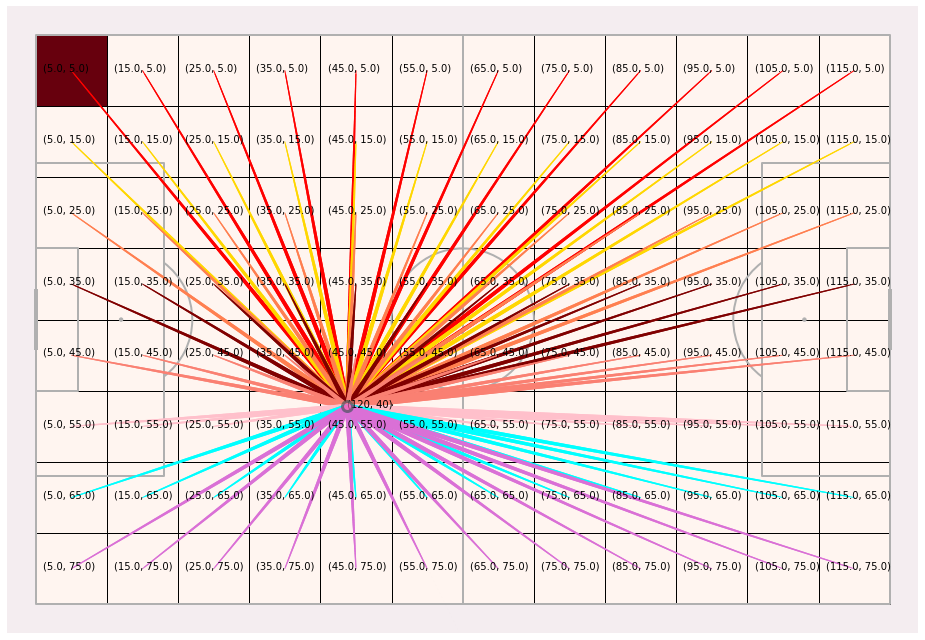

In [75]:
fig, ax = pitch.draw(figsize=(18,9))

pitch.heatmap(pixel_center_location_12x8, ax=ax, cmap='Reds', edgecolor='black')
pitch.scatter(ball_x, ball_y,
              ax=ax, fc='hotpink',
              marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)
ax.text(ball_x, ball_y,
        s=f"{(center_goal_location[0], center_goal_location[1])}",color='black')

for i in range(8):
    for j in range(12):
        #각 pixel 중앙 pixel number
        ax.text(x=pixel_center_location_12x8['cx'][i][j]-4,
                y=pixel_center_location_12x8['cy'][i][j],
                s=f"{(pixel_center_location_12x8['cx'][i][j],pixel_center_location_12x8['cy'][i][j])}")
        
        #pixel중앙 - 공 사이의 거리
        pitch.lines(xstart=pixel_center_location_12x8['cx'][i][j],
                    ystart=pixel_center_location_12x8['cy'][i][j],
                xend=ball_x,yend=ball_y,
                ax=ax, comet=True,color=color[i])

In [76]:
Distance_to_ball_dense_matrix_numpy_array = np.zeros((8,12))
for i in tqdm.tqdm(range(8)):
    for j in range(12):
        start_x, start_y = pixel_center_location_12x8['cx'][i][j], pixel_center_location_12x8['cy'][i][j]
        #볼 위치값
        end_x, end_y = ball_x, ball_y
        
        #pixel중앙 - 공 사이의 유클리디안 거리
        distance = ((end_x-start_x)*(end_x-start_x) + (end_y-start_y)*(end_y-start_y))**0.5
        Distance_to_ball_dense_matrix_numpy_array[i][j] = distance

100%|██████████| 8/8 [00:00<00:00, 8373.95it/s]


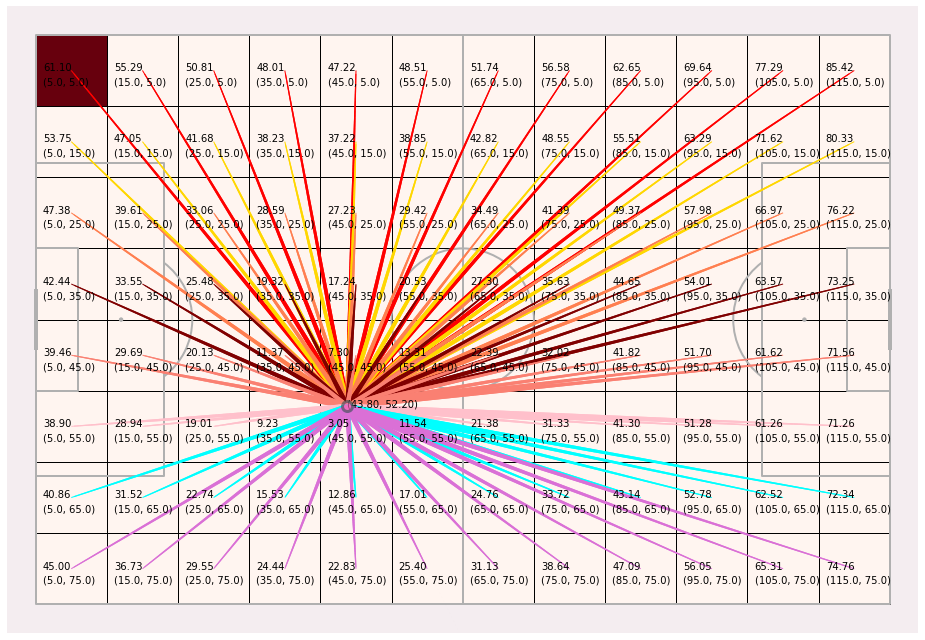

In [78]:
fig, ax = pitch.draw(figsize=(18,9))

pitch.heatmap(pixel_center_location_12x8, ax=ax, cmap='Reds', edgecolor='black')
pitch.scatter(ball_x, ball_y,
              ax=ax, fc='hotpink',
              marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)
ax.text(ball_x, ball_y,
        s=f"({ball_x:.2f}, {ball_y:.2f})",color='black')

for i in range(8):
    for j in range(12):
        #각 pixel 중앙 - 공 사이의 거리
        ax.text(x=pixel_center_location_12x8['cx'][i][j]-4,
                y=pixel_center_location_12x8['cy'][i][j],
                s=f"{Distance_to_ball_dense_matrix_numpy_array[i][j]:.2f}")
        #각 pixel 중앙에 pixel number
        ax.text(x=pixel_center_location_12x8['cx'][i][j]-4,
                y=pixel_center_location_12x8['cy'][i][j]+2,
                s=f"{(pixel_center_location_12x8['cx'][i][j],pixel_center_location_12x8['cy'][i][j])}")
        pitch.lines(xstart=pixel_center_location_12x8['cx'][i][j],
                    ystart=pixel_center_location_12x8['cy'][i][j],
                xend=ball_x,yend=ball_y,
                ax=ax, comet=True,color=color[i])

- 68x104구장에서 distance to the ball계산
- 각 데이터의 볼 위치를 기준으로 계산

In [79]:
Distance_to_ball_dense_matrix = np.zeros((len(pass_df),68,104))

for i in tqdm.tqdm(range(len(pass_df))):
    for coordinate in pass_df.iloc[i]['freeze_frame']:
        x,y = [coordinate['location'][0], coordinate['location'][1]]
        #공 소유자의 위치만 알면 됨
        if coordinate['actor']:
            ball_x, ball_y = x,y
            break
    #하나의 데이터의 68x104 pixel-ball사이의 거리를 매번 계산
    Distance_to_ball_dense_matrix_numpy_array = np.zeros((68,104))
    for row in range(68):
        for col in range(104):
            start_x, start_y = pixel_center_location_104x68['cx'][row][col], pixel_center_location_104x68['cy'][row][col]
            #볼 위치 값
            end_x, end_y = ball_x, ball_y
            
            distance = ((end_x-start_x)*(end_x-start_x) + (end_y-start_y)*(end_y-start_y))**0.5
            Distance_to_ball_dense_matrix_numpy_array[row][col] = distance
            
    Distance_to_ball_dense_matrix[i] = Distance_to_ball_dense_matrix_numpy_array

100%|██████████| 114554/114554 [57:18<00:00, 33.32it/s]


- Distance to goal and ball matrix 저장하기

In [80]:
import numpy as np
import os

# 저장할 디렉토리 생성
directory = 'Feature Matrix/Distance to goal matrix'
os.makedirs(directory, exist_ok=True)

# 각각의 데이터를 파일로 저장
for i in tqdm.tqdm(range(len(Distance_to_goal_dense_matrix))):
    filename = os.path.join(directory, f'Distance_to_goal_{i}.txt')
    with open(filename, 'w') as file:
        np.savetxt(file, Distance_to_goal_dense_matrix[i], delimiter=',')
        
directory = 'Feature Matrix/Distance to ball matrix'
os.makedirs(directory, exist_ok=True)

# 각각의 데이터를 파일로 저장
for i in tqdm.tqdm(range(len(Distance_to_ball_dense_matrix))):
    filename = os.path.join(directory, f'Distance_to_ball_{i}.txt')
    with open(filename, 'w') as file:
        np.savetxt(file, Distance_to_ball_dense_matrix[i], delimiter=',')


100%|██████████| 114554/114554 [10:34<00:00, 180.61it/s]


### 9. 모든 pixel에서 골까지 각도 dense matrix

- 모든 pixel에서 양끌 골대를 이를때 나오는 각도 dense matrix
- 모든 pixel의 중앙 위치 - 양쪽 골대를 잇는 각도
- 각도 단위는 라디안을 활용
- 두 고정된 벡터 사이의 각도 : 어느 data이든 항상 동일한 값을 가짐

In [11]:
#양쪽 골대의 위치를 기준으로 각도 측정
up_goal_location = (120,36)
down_goal_location = (120,44)

In [12]:

#key_point를 기준으로 (x1,y1)를 잇는 vector1
#key_point를 기준으로 (x2,y2)를 잇는 vector2
#vector1, vector2를 잇는 각도를 계산하는 함수
def calculate_angle(key_point_x, key_point_y, point_x1, point_y1, point_x2, point_y2,kind):
    # 벡터의 차분 계산
    vector1 = (point_x1 - key_point_x, point_y1 - key_point_y)
    vector2 = (point_x2 - key_point_x, point_y2 - key_point_y)
    
    # 벡터의 내적 계산
    dot_product = np.dot(vector1, vector2)

    # 벡터의 크기 계산
    # 주의 사항!! => (math.sqrt(vector1[0]**2 + vector1[1]**2))작성시 오류 발생
    # vecotr1[0]=-42.0일시 (-42.0**2)과 (-42.0*-42.0)의결과는 다름
    # 연산자 우선순위 때문에, (-42.0**2) = -1764가 나오고, (-42.0*-42.0) = 1764이 나오므로 주의!
    # magnitude1 = math.sqrt(vector1[0]**2 + vector1[1]**2)
    # magnitude2 = math.sqrt(vector2[0]**2 + vector2[1]**2)
    magnitude1 = (vector1[0]*vector1[0] + vector1[1]*vector1[1])**0.5
    magnitude2 = (vector2[0]*vector2[0] + vector2[1]*vector2[1])**0.5
    
    #warning이 가끔씩 뜨는데, 원인은 : ball location == pixel center location일 때 발생
    #두 위치가 같으면 하나의 vector=(0,0)이 되므로 dot_product=magnitude1=0의 값이 나와서 경고문이 뜨지만 문제없음
    cos_theta = dot_product / (magnitude1 * magnitude2)
    
    #연산과정에서 -1.0000002와 같이 -1 or 1를 약간 넘어가는 부분은
    #math.acos과정에서 오류가 발생함으로 예외처리해줌
    if cos_theta <-1:
        cos_theta = -1
    if cos_theta > 1:
        cos_theta = 1
        
    # 각도 변환
    radians = math.acos(cos_theta)
    degrees = math.degrees(radians)
    
    #Sine, Cosine, Degree, Radian 원하는 값 추출
    if kind == "Sine":
        result = math.sin(radians)
    elif kind == "Cosine":
        result = math.cos(radians)
    elif kind == "Degree":
        return degrees
    elif kind == "Radian":
        result = radians
    else:
        print("error kind name")
    return result

ex) 8x12구장에서 골까지 각도를 계산해보자

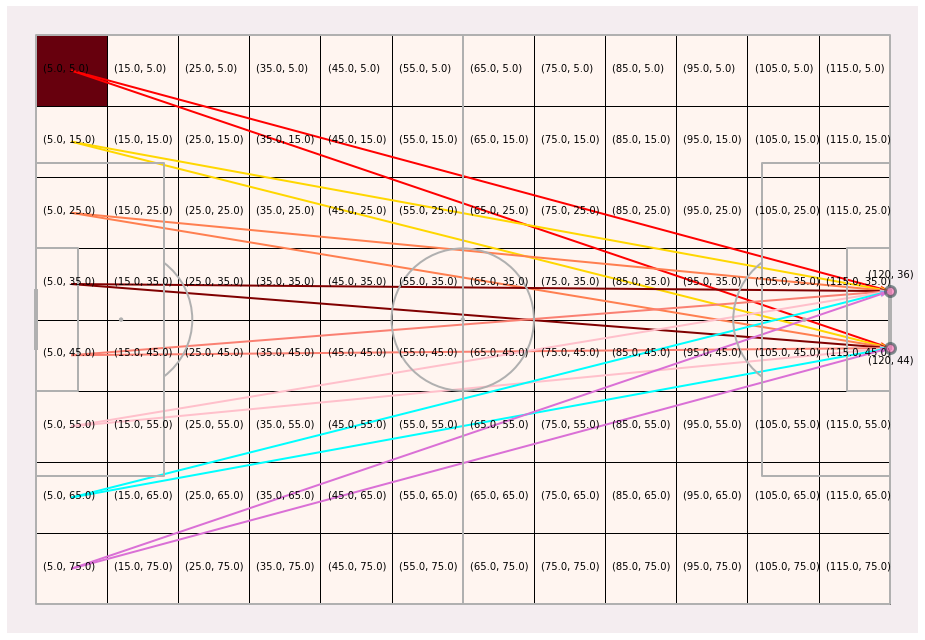

In [92]:
fig, ax = pitch.draw(figsize=(18,9))

pitch.heatmap(pixel_center_location_12x8, ax=ax, cmap='Reds', edgecolor='black')
pitch.scatter(up_goal_location[0], up_goal_location[1],
              ax=ax, fc='hotpink',
              marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)
pitch.scatter(down_goal_location[0], down_goal_location[1],
              ax=ax, fc='hotpink',
             marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)

ax.text(up_goal_location[0]-3,up_goal_location[1]-2,s=f"{(up_goal_location[0],up_goal_location[1])}",color='black')
ax.text(down_goal_location[0]-3,down_goal_location[1]+2,s=f"{(down_goal_location[0],down_goal_location[1])}",color='black')

for i in range(8):
    for j in range(12):
        if j==0:
                pitch.arrows(xstart=pixel_center_location_12x8['cx'][i][j],ystart=pixel_center_location_12x8['cy'][i][j],
                        xend=up_goal_location[0],yend=up_goal_location[1],
                        ax=ax,color=color[i],width=2)
                pitch.arrows(xstart=pixel_center_location_12x8['cx'][i][j],ystart=pixel_center_location_12x8['cy'][i][j],
                        xend=down_goal_location[0],yend=down_goal_location[1],
                        ax=ax,color=color[i],zorder=1,width=2)

        #각 pixel 중앙에 pixel number
        ax.text(x=pixel_center_location_12x8['cx'][i][j]-4,
                y=pixel_center_location_12x8['cy'][i][j],
                s=f"{(pixel_center_location_12x8['cx'][i][j],pixel_center_location_12x8['cy'][i][j])}")

In [93]:
Radian_to_goal_dense_matrix_numpy_array = np.zeros((8,12))
for i in tqdm.tqdm(range(8)):
    for j in range(12):
        start_x, start_y = pixel_center_location_12x8['cx'][i][j], pixel_center_location_12x8['cy'][i][j]      
        #Angle to goal은 radian값을 활용
        angle = calculate_angle(start_x, start_y,up_goal_location[0],up_goal_location[1],
                                down_goal_location[0],down_goal_location[1],"Radian")      
        Radian_to_goal_dense_matrix_numpy_array[i][j] = angle

100%|██████████| 8/8 [00:00<00:00, 2694.92it/s]


In [94]:
Radian_to_goal_dense_matrix_numpy_array.shape

(8, 12)

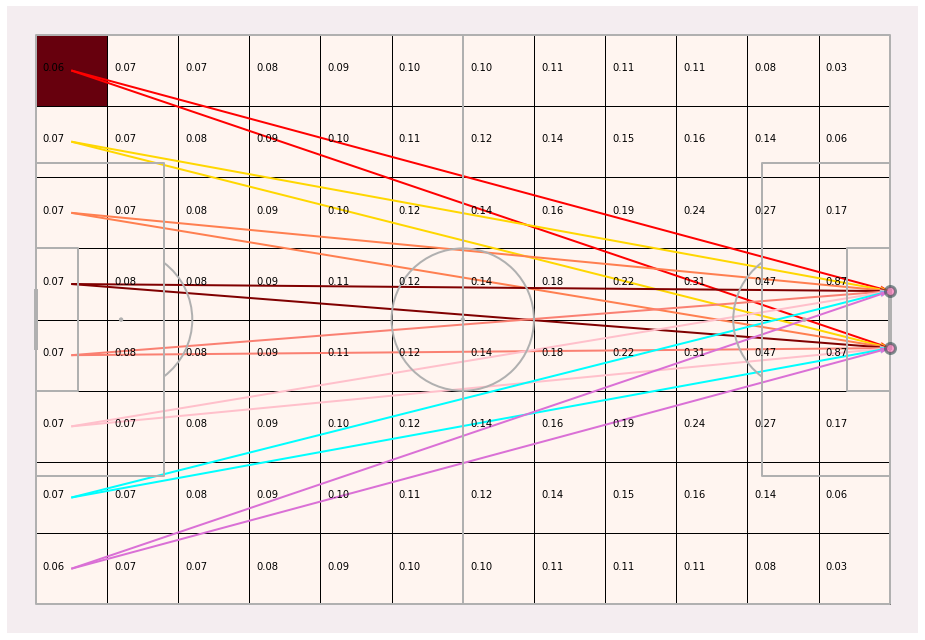

In [96]:
fig, ax = pitch.draw(figsize=(18,9))

pitch.heatmap(pixel_center_location_12x8, ax=ax, cmap='Reds', edgecolor='black')
pitch.scatter(up_goal_location[0], up_goal_location[1],
              ax=ax, fc='hotpink',
              marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)
pitch.scatter(down_goal_location[0], down_goal_location[1],
              ax=ax, fc='hotpink',
             marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)

for i in range(8):
    for j in range(12):
        if j==0:
                pitch.arrows(xstart=pixel_center_location_12x8['cx'][i][j],ystart=pixel_center_location_12x8['cy'][i][j],
                        xend=up_goal_location[0],yend=up_goal_location[1],
                        ax=ax,color=color[i],width=2)
                pitch.arrows(xstart=pixel_center_location_12x8['cx'][i][j],ystart=pixel_center_location_12x8['cy'][i][j],
                        xend=down_goal_location[0],yend=down_goal_location[1],
                        ax=ax ,color=color[i],width=2)
        
        ax.text(x=pixel_center_location_12x8['cx'][i][j]-4,
                y=pixel_center_location_12x8['cy'][i][j],
                #골까지 Radian
                s=f"{Radian_to_goal_dense_matrix_numpy_array[i][j]:.2f}")


- 68x104구장에서 Angle to the goal 계산

In [23]:
Radian_to_goal_dense_matrix_numpy_array = np.zeros((68,104))
for i in tqdm.tqdm(range(68)):
    for j in range(104):
        start_x, start_y = pixel_center_location_104x68['cx'][i][j], pixel_center_location_104x68['cy'][i][j]      
        angle = calculate_angle(start_x, start_y,up_goal_location[0],up_goal_location[1],
                                down_goal_location[0],down_goal_location[1],"Radian")         
        Radian_to_goal_dense_matrix_numpy_array[i][j] = angle

100%|██████████| 68/68 [00:00<00:00, 1825.88it/s]


In [24]:
Radian_to_goal_dense_matrix_numpy_array.shape

(68, 104)

- 114,554개의 데이터 모두 Angle to goal의 matrix는 동일한 값을 가짐

In [25]:
Radian_to_goal_dense_matrix = np.zeros((len(pass_df), 68, 104))
Radian_to_goal_dense_matrix = np.array([Radian_to_goal_dense_matrix_numpy_array for _ in range(len(pass_df))])

In [27]:
Radian_to_goal_dense_matrix.shape

(114554, 68, 104)

### 10. 모든 pixel에서 골-공 사이 sin값 dense matrix(pixel중앙-골 & pixcel중앙-공 두 벡터 사이의 sin값)
### 11. 모든 pixel에서 골-공 사이 cos값 dense matrix(pixel중앙-골 & pixcel중앙-공 두 벡터 사이의 cos값)

- 모든 pixel에서 볼 위치 - 골대 중앙를 이를때 나오는 각도 dense matrix
- 모든 pixel의 볼 위치 - 골대 중앙를 잇는 각도
- 각도 단위는 Degree에 Sine, Cosine를 적용함
- 각 데이터마다 공 소유자 위치가 다르므로 따로 처리

ex) 8x12구장에서 공-골까지 각도를 계산해보자

In [103]:
pitch = Pitch(line_zorder=2, pitch_color='#f4edf0')
i = 0
for coordinate in pass_df.iloc[i]['freeze_frame']:
    x,y = [coordinate['location'][0], coordinate['location'][1]]
    if coordinate['actor']:
        ball_x, ball_y = x,y

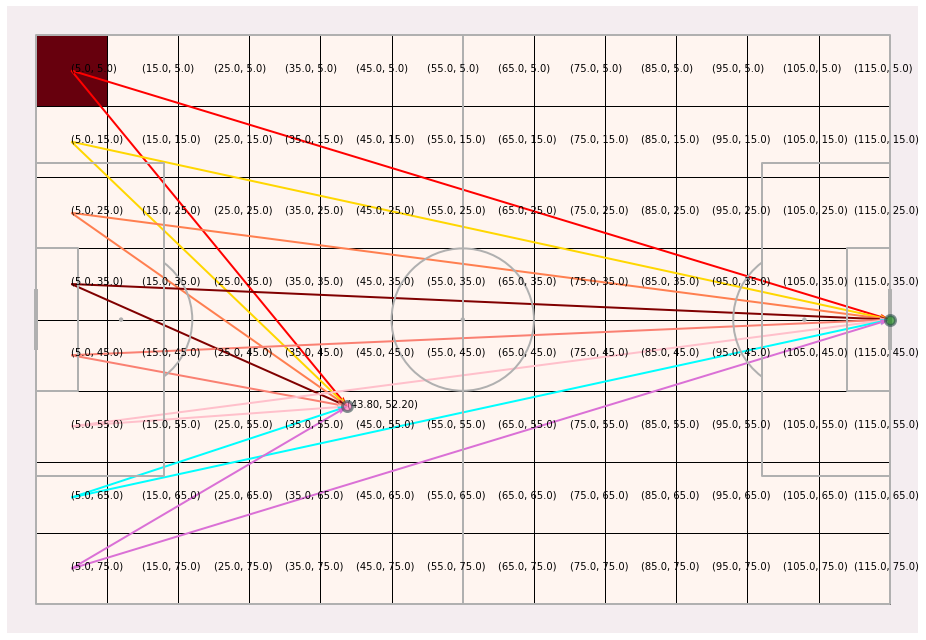

In [109]:
fig, ax = pitch.draw(figsize=(18,9))

pitch.heatmap(pixel_center_location_12x8, ax=ax, cmap='Reds', edgecolor='black')
pitch.scatter(ball_x, ball_y,
              ax=ax, fc='hotpink',
              marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)
pitch.scatter(center_goal_location[0],center_goal_location[1],
              ax=ax, fc='green',
              marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)
ax.text(ball_x, ball_y,
        s=f"({ball_x:.2f}, {ball_y:.2f})",color='black')

for i in range(8):
    for j in range(12):
        #각 pixel 중앙에 pixel number
        ax.text(x=pixel_center_location_12x8['cx'][i][j],
                y=pixel_center_location_12x8['cy'][i][j],
                s=f"{(pixel_center_location_12x8['cx'][i][j],pixel_center_location_12x8['cy'][i][j])}")
        if j==0:
                pitch.arrows(xstart=pixel_center_location_12x8['cx'][i][j],ystart=pixel_center_location_12x8['cy'][i][j],
                        xend=ball_x,yend=ball_y,
                        ax=ax,color=color[i],width=2)
                pitch.arrows(xstart=pixel_center_location_12x8['cx'][i][j],ystart=pixel_center_location_12x8['cy'][i][j],
                        xend=center_goal_location[0],yend=center_goal_location[1],
                        ax=ax,color=color[i],width=2)

- Sine 계산

In [123]:
Sine_between_ball_goal_dense_matrix_numpy_array = np.zeros((8,12))
for i in tqdm.tqdm(range(8)):
    for j in range(12):
        start_x, start_y = pixel_center_location_12x8['cx'][i][j], pixel_center_location_12x8['cy'][i][j]      
        angle = calculate_angle(start_x, start_y,ball_x,ball_y,center_goal_location[0],center_goal_location[1],"Sine")      
        Sine_between_ball_goal_dense_matrix_numpy_array[i][j] = angle

100%|██████████| 8/8 [00:00<00:00, 2251.07it/s]


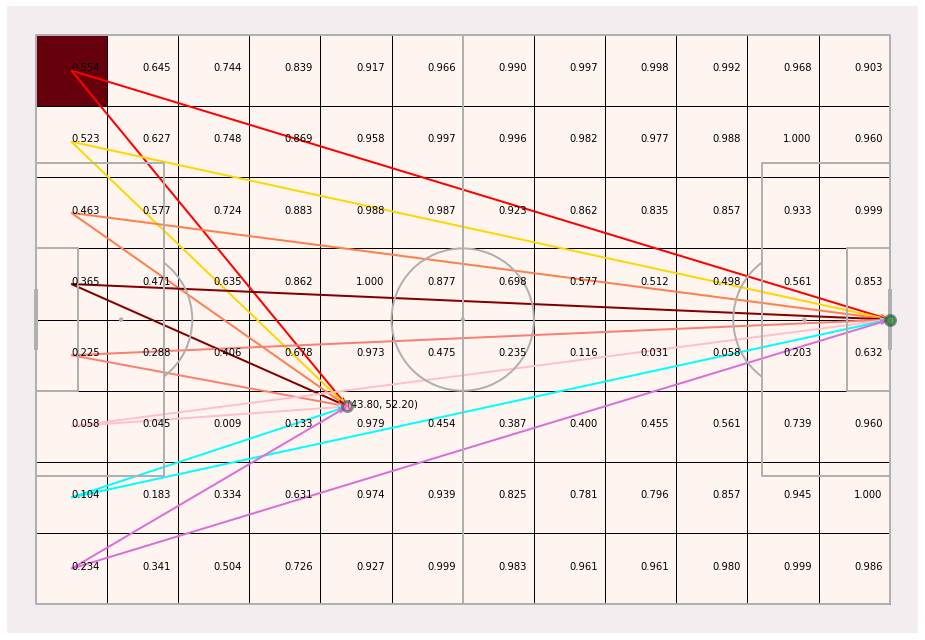

In [124]:
fig, ax = pitch.draw(figsize=(18,9))

pitch.heatmap(pixel_center_location_12x8, ax=ax, cmap='Reds', edgecolor='black')
pitch.scatter(ball_x, ball_y,
              ax=ax, fc='hotpink',
              marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)
pitch.scatter(center_goal_location[0],center_goal_location[1],
              ax=ax, fc='green',
              marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)
ax.text(ball_x, ball_y,
        s=f"({ball_x:.2f}, {ball_y:.2f})",color='black')

for i in range(8):
    for j in range(12):
        #각 pixel 중앙에 pixel number
        ax.text(x=pixel_center_location_12x8['cx'][i][j],
                        y=pixel_center_location_12x8['cy'][i][j],
                        s=f"{Sine_between_ball_goal_dense_matrix_numpy_array[i][j]:.3f}")
        if j==0:
                pitch.arrows(xstart=pixel_center_location_12x8['cx'][i][j],ystart=pixel_center_location_12x8['cy'][i][j],
                        xend=ball_x,yend=ball_y,
                        ax=ax,color=color[i],width=2)
                pitch.arrows(xstart=pixel_center_location_12x8['cx'][i][j],ystart=pixel_center_location_12x8['cy'][i][j],
                        xend=center_goal_location[0],yend=center_goal_location[1],
                        ax=ax,color=color[i],width=2)

- Cosine계산

In [125]:
Cosine_between_ball_goal_dense_matrix_numpy_array = np.zeros((8,12))
for i in tqdm.tqdm(range(8)):
    for j in range(12):
        start_x, start_y = pixel_center_location_12x8['cx'][i][j], pixel_center_location_12x8['cy'][i][j]      
        angle = calculate_angle(start_x, start_y,ball_x,ball_y,center_goal_location[0],center_goal_location[1],"Cosine")      
        Cosine_between_ball_goal_dense_matrix_numpy_array[i][j] = angle

100%|██████████| 8/8 [00:00<00:00, 2096.10it/s]


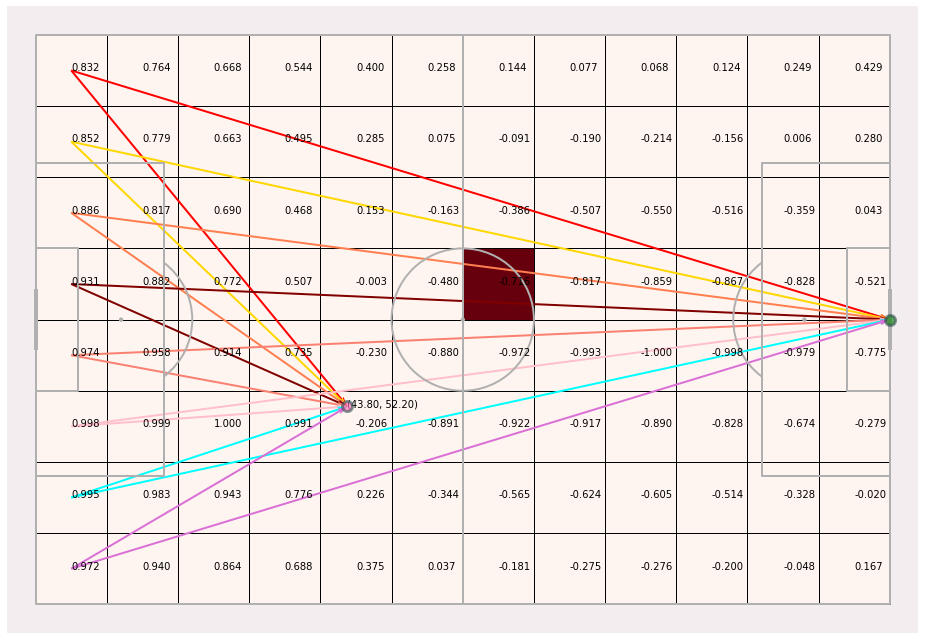

In [126]:
fig, ax = pitch.draw(figsize=(18,9))

pitch.heatmap(bin_statistic, ax=ax, cmap='Reds', edgecolor='black')
pitch.scatter(ball_x, ball_y,
              ax=ax, fc='hotpink',
              marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)
pitch.scatter(center_goal_location[0],center_goal_location[1],
              ax=ax, fc='green',
              marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)
ax.text(ball_x, ball_y,
        s=f"({ball_x:.2f}, {ball_y:.2f})",color='black')

for i in range(8):
    for j in range(12):
        ax.text(x=bin_statistic['cx'][i][j],
                        y=bin_statistic['cy'][i][j],
                        #각 pixel 중앙에 pixel number
                        s=f"{Cosine_between_ball_goal_dense_matrix_numpy_array[i][j]:.3f}")
        if j==0:
                pitch.arrows(xstart=bin_statistic['cx'][i][j],ystart=bin_statistic['cy'][i][j],
                        xend=ball_x,yend=ball_y,
                        ax=ax,color=color[i],width=2)
                pitch.arrows(xstart=bin_statistic['cx'][i][j],ystart=bin_statistic['cy'][i][j],
                        xend=center_goal_location[0],yend=center_goal_location[1],
                        ax=ax,color=color[i],width=2)

- 68x104구장에서 Angle to the goal 계산

In [13]:
Sine_between_ball_and_goal_dense_matrix = np.zeros((len(pass_df),68,104))

for i in tqdm.tqdm(range(len(pass_df))):
    for coordinate in pass_df.iloc[i]['freeze_frame']:
        x,y = [coordinate['location'][0], coordinate['location'][1]]
        #볼 소유자의 위치만 알면 됨
        if coordinate['actor']:
            ball_x, ball_y = x,y
            break
        
    Sine_between_ball_and_goal_dense_matrix_numpy_array = np.zeros((68,104))
    for row in range(68):
        for col in range(104):
            start_x, start_y = pixel_center_location_104x68['cx'][row][col], pixel_center_location_104x68['cy'][row][col]
            #공-골대 중앙을 잇는 Sine구하기
            angle = calculate_angle(start_x, start_y,ball_x,ball_y,center_goal_location[0],center_goal_location[1],"Sine")      
            Sine_between_ball_and_goal_dense_matrix_numpy_array[row][col] = angle
                
    Sine_between_ball_and_goal_dense_matrix[i] = Sine_between_ball_and_goal_dense_matrix_numpy_array

100%|██████████| 114554/114554 [1:19:09<00:00, 24.12it/s]


In [14]:
Cosine_between_ball_and_goal_dense_matrix = np.zeros((len(pass_df),68,104))

for i in tqdm.tqdm(range(len(pass_df))):
    for coordinate in pass_df.iloc[i]['freeze_frame']:
        x,y = [coordinate['location'][0], coordinate['location'][1]]
        #볼 소유자의 위치만 알면 됨
        if coordinate['actor']:
            ball_x, ball_y = x,y
            break
        
    Cosine_between_ball_and_goal_dense_matrix_numpy_array = np.zeros((68,104))
    for row in range(68):
        for col in range(104):
            start_x, start_y = pixel_center_location_104x68['cx'][row][col], pixel_center_location_104x68['cy'][row][col]      
            #공-골대중앙을 잇는 Cosine구하기
            angle = calculate_angle(start_x, start_y,ball_x,ball_y,center_goal_location[0],center_goal_location[1],"Cosine")      
            Cosine_between_ball_and_goal_dense_matrix_numpy_array[row][col] = angle
            
    Cosine_between_ball_and_goal_dense_matrix[i] = Cosine_between_ball_and_goal_dense_matrix_numpy_array

100%|██████████| 114554/114554 [1:18:40<00:00, 24.27it/s]


- Radian to goal 저장하기
- Sine and Cosine between goal and ball matrix 저장하기

In [28]:
total_files = 114554

#저장할 디렉토리 생성
directory = 'Feature Matrix/Radian to goal matrix'
os.makedirs(directory, exist_ok=True)

# 각각의 데이터를 파일로 저장
for i in tqdm.tqdm(range(total_files)):
    filename = os.path.join(directory, f'Radian_to_goal_{i}.txt')
    with open(filename, 'w') as file:
        np.savetxt(file, Radian_to_goal_dense_matrix[i], delimiter=',')
        
directory = 'Feature Matrix/Sine between goal and ball matrix'
os.makedirs(directory, exist_ok=True)

# 각각의 데이터를 파일로 저장
for i in tqdm.tqdm(range(total_files)):
    filename = os.path.join(directory, f'Sine_between_goal_and_ball_{i}.txt')
    with open(filename, 'w') as file:
        np.savetxt(file, Sine_between_ball_and_goal_dense_matrix[i], delimiter=',')
        
directory = 'Feature Matrix/Cosine between goal and ball matrix'
os.makedirs(directory, exist_ok=True)

# 각각의 데이터를 파일로 저장
for i in tqdm.tqdm(range(total_files)):
    filename = os.path.join(directory, f'Cosine_between_goal_and_ball_{i}.txt')
    with open(filename, 'w') as file:
        np.savetxt(file, Cosine_between_ball_and_goal_dense_matrix[i], delimiter=',')


100%|██████████| 114554/114554 [11:13<00:00, 169.97it/s]
